## Simple Linear Regression

#### one independent or input feature 
#### one dependent or output feature

In [138]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
df = pd.read_csv("simple_linear_dataset.csv")
df.head() 

,Height_cm,Weight_kg
0,150,45
1,151,49
2,152,54
3,153,44
4,154,42


Text(0, 0.5, 'Height_cm')

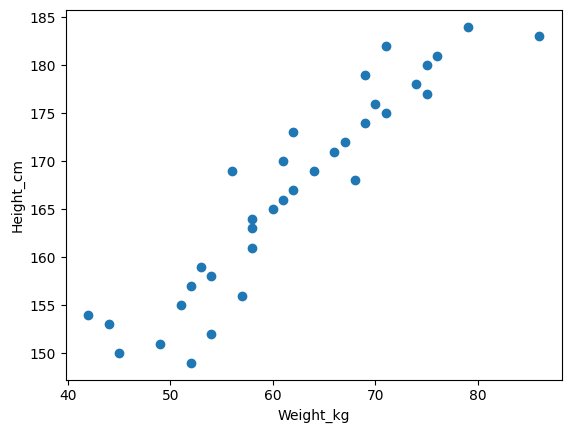

In [ ]:
 ## scatter plot 
plt.scatter(df['Weight_kg'],df['Height_cm']) # helps to identify inear relationship exists or not 
plt.xlabel("Weight_kg")
plt.ylabel("Height_cm")

In [ ]:
## Correlation: Measures how strongly two variable move together 
# height increase weight usually increase
df.corr() # near +1 strong relationship (+ve)

,Height_cm,Weight_kg
Height_cm,1.000000,0.933066
Weight_kg,0.933066,1.000000


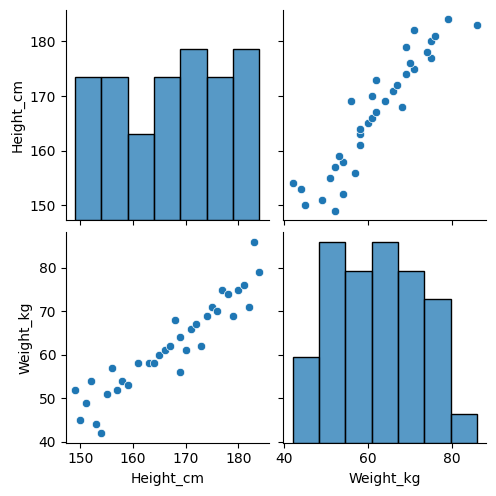

In [ ]:
## Seaborn for visualization : help to visualize relationship between all variable 
import seaborn as sns
sns.pairplot(df)

In [269]:
## Independent features
X = df['Weight_kg']
type(X) # it is a series 
# type(df) it is a dataframe


pandas.Series

In [ ]:

X = df[['Weight_kg']]
type(X) # will be dataframe 
# X or independent feature must be dataframe or 2d array not a series
 

pandas.DataFrame

In [271]:
# Dependent feature
Y = df['Height_cm'] # This variable can be in series for or 1d array
Y

0     150
1     151
2     152
3     153
4     154
5     155
6     156
7     157
8     158
9     159
10    169
11    161
12    149
13    163
14    164
15    165
16    166
17    167
18    168
19    169
20    170
21    171
22    172
23    173
24    174
25    175
26    176
27    177
28    178
29    179
30    180
31    181
32    182
33    183
34    184
Name: Height_cm, dtype: int64

In [272]:
## Train Test Split
from sklearn.model_selection import train_test_split

In [273]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.25,random_state=42)

In [ ]:
X_train.shape

# Training data -> learn patterns 
# Testing data -> Evaluate performace 

(26, 1)

In [ ]:
## Standardlization : Bringing all feature to similar range. 
from sklearn.preprocessing import StandardScaler
# z = (x-mean)/std
#std = 1
#mean = 0


In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
# z score test


In [ ]:
X_test = scaler.transform(X_test)

In [296]:
X_test

array([[ 0.71555115],
       [-0.33258011],
       [ 0.62820688],
       [ 0.36617406],
       [-0.15789157],
       [ 0.62820688],
       [ 0.19148552],
       [-0.85664575],
       [-0.6819572 ]])

#### Applying Simple Linear Regression Algorithm

In [315]:
from sklearn.linear_model import LinearRegression

In [316]:
regression = LinearRegression(n_jobs=-1)

In [317]:
regression.fit(X_train,Y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",-1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[10.24]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,166.8
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.1]


In [ ]:
print("Coefficeint or slope: ",regression.coef_) 
print("Intercept: ",regression.intercept_)
# 1 unit movement in weight value leads to 10.23 movement in the height value 
# When weight is zero at what point your line is meeting y axis or height axis (166.8076)


Coefficeint or slope:  [10.23620603]
Intercept:  166.80769230769232


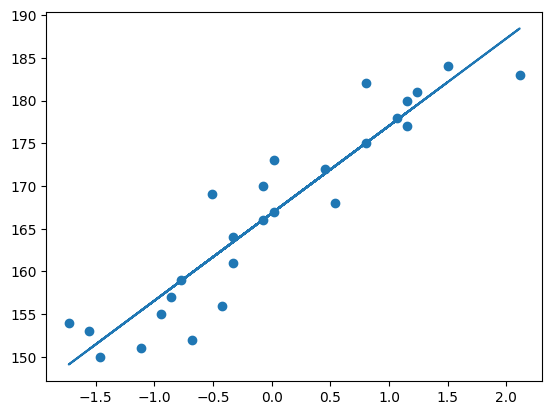

In [319]:
## Plot Tarining data plot best fit line 
plt.scatter(X_train,Y_train)
plt.plot(X_train,regression.predict(X_train)) #best fit line

##### Prediction for test data
1. predicted height output = intercept + coef_(Weight)
2. y_pred_test = 166.80 + 10.23(X_test)

In [320]:
## Prediction for test data
y_pred=regression.predict(X_test)
y_pred

array([174.13222133, 163.40333375, 173.23814737, 170.55592547,
       165.19148168, 173.23814737, 168.76777754, 158.03888995,
       159.82703789])

In [321]:
## Performace Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error


In [322]:
mse = mean_squared_error(Y_test,y_pred)
mae = mean_absolute_error(Y_test,y_pred)
rmse = np.sqrt(mse)
print("MSE = ",mse)
print("MAE = ",mae)
print("RMSE = ",rmse)

MSE =  13.639781578981006
MAE =  2.280947132282778
RMSE =  3.6932074920021765


#### R Square

formula = R square = 1 - SSR/SST

In [323]:
from sklearn.metrics import r2_score


In [324]:
score = r2_score(Y_test,y_pred)
print(score)

0.8292392105258947


#### Adjusted R Square

formula = Adjusted R Square = 1-[(1-R2)*(n-1)/(n-k-1)]

In [325]:
1 - (1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.8048448120295939

#### OLS Linear Regression

In [326]:
import statsmodels.api as sm

In [327]:
model= sm.OLS(Y_train,X_train).fit()

In [328]:
prediction = model.predict(X_test)
print(prediction)

[ 7.32452902 -3.40435856  6.43045506  3.74823316 -1.61621063  6.43045506
  1.96008523 -8.76880235 -6.98065442]


In [329]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:              Height_cm   R-squared (uncentered):                   0.004
Model:                            OLS   Adj. R-squared (uncentered):             -0.036
Method:                 Least Squares   F-statistic:                            0.09409
Date:                Tue, 23 Jun 2026   Prob (F-statistic):                       0.762
Time:                        16:18:14   Log-Likelihood:                         -169.94
No. Observations:                  26   AIC:                                      341.9
Df Residuals:                      25   BIC:                                      343.1
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [330]:
## Prediction for new data
regression.predict([[72]])

array([903.81452632])

In [331]:
regression.predict(scaler.transform([[72]]))

c:\Users\Manis\OneDrive\vs COdE Python\Data-Science-Journey\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([175.92036926])